<div style="text-align: center;">
<strong>Machine Learning for Scientific Computing and Numerical Analysis - Practical 6</strong>
</div>
<div style="text-align: center;">
<i>Reduced Basis Galerkin Methods</i>
</div>
<div style="text-align: center;">
</br>
<p>Victorita Dolean, Loïc Gouarin, Rémy Hosseinkhan, Hadrien Montanelli
</br>
2025-2026
</p>
</div>

This notebook combines:
1. RB-Galerkin for the Poisson equation
2. RB-Galerkin for a varying-coefficient elliptic equation
3. RB-Galerkin for the heat equation
4. RB-Galerkin for the viscous Burgers equation

---
# PART 1: RB-Galerkin for Poisson equation

# 1 Imports and helper functions

In [3]:
from math import pi
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
import time

def chebpts(n, dom=[-1, 1]):
    """Return n Chebyshev points of the second kind."""

    if n == 1:
        x = np.array([-1])
    else:
        x = -np.cos(np.array([j for j in range(n)])*np.pi/(n-1))
    x = dom[1]*(x + 1)/2 + dom[0]*(1 - x)/2

    return x

def quadwts(n, dom=[-1, 1]):
    """Return n weights for Clenshaw-Curtis quadrature."""

    c = 2/np.concatenate(([1],  1 - np.arange(2, n, 2)**2), axis=0)
    c = np.concatenate((c, c[int(n/2)-1:0:-1]), axis=0)
    w = np.real(np.fft.ifft(c))
    w[0] = w[0]/2
    w = np.concatenate((w, [w[0]]), axis=0)
    w = (dom[1] - dom[0])/2*w

    return w

# 2 RB-Galerkin for Poisson equation

We consider the one-dimensional Poisson equation with homogeneous Dirichlet boundary conditions:

\begin{align}
& -u''(x;\mu) = f(x;\mu), \quad x \in[0,1], \\
& \phantom{-}u(0;\mu) = u(1;\mu) = 0.
\end{align}

We will take the following righ-hand side $f$ and exact solution,
$$
f(x;\mu) = e^{-5(x - \mu)^2}, \qquad u(x;\mu) = \int_0^1g(x,y)f(y;\mu)dy, \qquad g(x,y) = \frac{1}{2}(x + y - \vert y-x\vert)-xy.
$$

The exact solution is computed from the Green's function $g$ with a Clenshaw-Curtis quadrature to approximate the integral; see, e.g., <a href="https://en.wikipedia.org/wiki/Green%27s_function" style="color: blue">this</a> and <a href="https://en.wikipedia.org/wiki/Clenshaw%E2%80%93Curtis_quadrature" style="color: blue">this</a>.

**Note: In this problem, the parameter $\mu$ comes from the right-hand side $f(\cdot;\mu)$.**

We discretize space with

$$
x_j = jh, \quad h=1/(N_h+1), \quad 0\leq j\leq N_h+1.
$$

We have the following $N_h$ basis functions on $[0, 1]$. Note the differences in $x_j$ and $h$ compared to $[-1,1]$. The $N_h$ degrees of freedom are the values at the $N_h$ interior grid points.

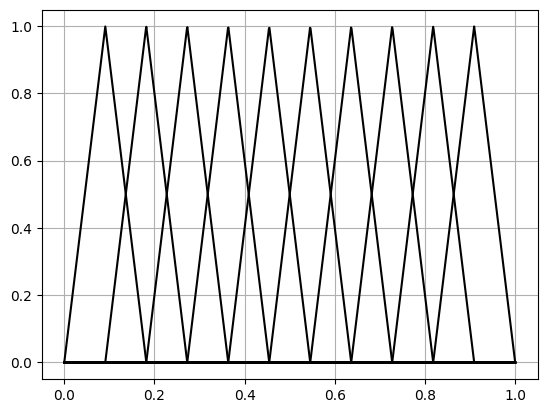

In [4]:
# Computation grid and basis functions:
N_h = 10
h = 1/(N_h + 1)
x_h = np.linspace(0, 1, N_h + 2)
phi = lambda x: (1 - np.abs(x)) * (np.abs(x) <= 1)
Phi = lambda i, x: phi((x - x_h[i])/h)

# Plot basis functions on a finer grid:
N_eval = 1000
x_eval = np.linspace(0, 1, N_eval + 1)
plt.figure()
for j in range(1, N_h + 1):
    plt.plot(x_eval, Phi(j, x_eval), 'k')
plt.grid();

## 2.1 Galerkin linear system

We seek a finite element approximation of $u$

$$
u_h(x;\mu) = \sum_{j=1}^{N_h} u_h^j(\mu)\phi_j(x), \qquad u_h^j(\mu) = u_h(x_j;\mu),
$$

which verifies the Galerkin variational problem

$$
\int_0^1 u_h'(x;\mu)\phi_i'(x)  dx  = \int_0^1 f(x;\mu)\phi_i(x)dx, \qquad 1\leq i\leq N_h.
$$

By substituting the expression for $u_h$, we obtain the following linear system,

$$
\sum_{j=1}^{N_h} u_h^j(\mu)\int_0^1 \phi_i'(x)\phi_j'(x)dx = \int_0^1 f(x;\mu)\phi_i(x)dx, \qquad 1\leq i\leq N_h.
$$

We set

$$
(A_h)_{ij} = \int_0^1 \phi_i'(x)\phi_j'(x)dx, \qquad (F_h(\mu))_i = \int_0^1 f(x;\mu)\phi_i(x)dx, \qquad (M_h)_{ij} = \int_0^1 \phi_i(x)\phi_j(x)dx.
$$

Then the $N_h\times N_h$ Galerkin linear system reads

$$
A_hU_h(\mu) = F_h(\mu) \approx M_h\widetilde{F}_h(\mu),
$$

with unknown $U_h(\mu) = (u_h^1(\mu),\ldots,u_h^{N_h}(\mu))^T$ and

$$
A_h = \frac{1}{h}\mathrm{tridiag}(-1, 2, -1), \quad M_h = \frac{h}{3}\mathrm{tridiag}(0.5, 2, 0.5), \quad \widetilde{F}_h(\mu) = \begin{pmatrix} f(x_1;\mu) \\ \vdots \\ f(x_{N_h};\mu) \end{pmatrix}.
$$

In other words,

$$
A_h = \frac{1}{h}\begin{pmatrix}
\phantom{-}2 & -1 \\
-1 & \phantom{-}2 & -1 \\
& \ddots & \ddots & \ddots \\
& & -1 & \phantom{-}2 & -1 \\
& & & -1 & \phantom{-}2
\end{pmatrix}, \qquad
M_h = \frac{h}{3}\begin{pmatrix}
2 & 0.5 \\
0.5 & 2 & 0.5 \\
& \ddots & \ddots & \ddots \\
& & 0.5 & 2 & 0.5 \\
& & & 0.5 & 2
\end{pmatrix}.
$$

We aslo recall that we can assemble the matrices and solve the Galerkin linear system like this.

In [6]:
def assemble_matrices(N_h):
    """
    Assemble the stiffness matrix A_h and mass matrix M_h for the Galerkin method.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.

    Returns
    -------
    A_h : scipy.sparse.csc_matrix
        The stiffness matrix of size (N_h, N_h).
    M_h : scipy.sparse.csc_matrix
        The mass matrix of size (N_h, N_h).
    """

    # Grid size:
    h = 1/(N_h + 1)

    # Stiffness matrix:
    d1 = [-1] * (N_h - 1)
    d0 = [2] * N_h
    A_h = 1/h * diags([d1, d0, d1], [-1, 0, 1], format='csc')

    # Mass matrix:
    d1 = [0.5] * (N_h - 1)
    M_h = h/3 *  diags([d1, d0, d1], [-1, 0, 1], format='csc')

    return A_h, M_h

def solve_galerkin(N_h, mu):
    """
    Solve the Galkerin linear system.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    mu : float
        The parameter for the right-hand side f.

    Returns
    -------
    np.ndarray
        The solution vector of size (N_h,).
    """

    # Grid:
    x_h = np.linspace(0, 1, N_h + 2)

    # Construct the matrices:
    A_h, M_h = assemble_matrices(N_h)

    # Solve the linear system:
    U_h = spsolve(A_h, M_h @ f(x_h[1:-1], mu))

    return U_h

### Validation

In [ ]:
# ODE setup:
mu = 0.5
f = lambda x, mu: np.exp(-5*(x - mu)**2)
g = lambda x, y: 0.5 * (x[:, None] + y - np.abs(x[:, None] - y)) - x[:, None] * y
y = chebpts(200, [0, 1])
w = quadwts(200, [0, 1])
u_ex = lambda x, mu: w @ (g(x, y).T * f(y, mu)[:, None])

# Grid setup:
N_h = 100
h = 1/(N_h + 1)
x_h = np.linspace(0, 1, N_h + 2) # computation grid
N_eval = 200
x_eval = np.linspace(0, 1, N_eval) # evaluation grid

# Solve Galerkin linear system:
start = time.time()
U_h = solve_galerkin(N_h, mu)
end = time.time()
print(f'Time (online): {end-start:.5f}s')

# Evalute the approximate solution on the evaluation grid:
I, XEVAL = np.meshgrid(np.arange(1, N_h + 1), x_eval)
u_h = Phi(I, XEVAL) @ U_h

# Compute the L-inf error:
error = np.max(np.abs(u_ex(x_eval, mu) - u_h))/np.max(np.abs(u_ex(x_eval, mu)))
print(f'Error (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval, f(x_eval, mu), '-k', label=r'$f(x; \mu = %.2f)$' % mu)
plt.plot(x_eval, u_h, '-', label=r'$u_h(x; \mu = %.2f)$' % mu)
plt.plot(x_eval, u_ex(x_eval, mu), '--', label=r'$u_\mathrm{exact}(x; \mu = %.2f)$' % mu)
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

## 2.2 Snapshots

Next, we assemble the snapshot matrix

$$
S = [U_h(\mu_1) | \ldots | U_h(\mu_n)] \in \R^{N_h\times n}.
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be around $10^{-4}$.

In [ ]:
def compute_snapshots(N_h, n, mu):
    """
    Compute a set of solution snapshots using the Galerkin method.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    n : int
        The number of parameter samples.
    mu : np.ndarray
        The vector of parameter values.

    Returns
    -------
    S : np.ndarray
        A matrix of shape (N_h, n) where each column is a solution snapshot.
    """

    # Initialize the matrix:
    S = None

    # Loop over the parameter values:
    for i in range(n):
        S[:, i] = None

    return S

### Validation

In [ ]:
# Compute snapshots:
n = 50
mu_val = np.linspace(0.25, 0.75, n)
start = time.time()
S = compute_snapshots(N_h, n, mu_val)
end = time.time()
print(f'Time (offline): {end-start:.5f}s')

# Compute exact snapshots:
S_ex = np.zeros((N_h, n))
for i in range(n):
    S_ex[:, i] = u_ex(x_h[1:-1], mu_val[i])

# Compute the L-inf error:
error = np.max(np.abs(S - S_ex))/np.max(np.abs(S_ex))
print(f'Error  (L-inf): {error:.2e}')

## 2.3 Reduced basis

Now, we compute the SVD of $S=U\Sigma V^T$ and set

$$
W = [U_1 | \ldots U_N] \in \R^{N_h\times N},
$$

where $N$ is chosen such that

$$
\frac{\sum_{j=1}^N\sigma_j^2}{\sum_{j=1}^r\sigma_j^2} \geq 1 - \epsilon^2.
$$

### Exercise

Complete the missing parts.

The singular values should decay to  $10^{-16}$ and $N$ should be equal to $5$, corresponding to a singular value around $10^{-6}$.

In [ ]:
def compute_reduced_basis(S, epsilon):
    """
    Computes a reduced basis using Singular Value Decomposition (SVD) by selecting the
    first N singular vectors that capture a desired amount of energy.

    Parameters
    ----------
    S : numpy.ndarray
        The input matrix for which the reduced basis is to be computed. It should be of shape (N_h, n).
    epsilon : float
        The energy threshold (0 < epsilon < 1). It determines the fraction of the total energy
        to be captured by the reduced basis.

    Returns
    -------
    W : numpy.ndarray
        The matrix of the first N singular vectors (reduced basis), with shape (N_h, N), where N is the
        number of singular vectors selected.
    Sigma : numpy.ndarray
        The vector of singular values of S.
    N : int
        The number of singular vectors selected, corresponding to the desired energy threshold.

    Notes
    -----
    The function performs an SVD on the input matrix `S`, computes the cumulative energy captured
    by the singular values, and selects the minimum number of singular vectors that capture at least
    (1 - epsilon^2) of the total energy.
    """

    # SVD:
    U, Sigma, VT = None

    # Choose N from epsilon:
    N = None

    # Select the first N singular vectors:
    W = None

    return W, Sigma, N

### Validation

In [ ]:
epsilon = 1e-6
W, Sigma, N = compute_reduced_basis(S, epsilon)
print(N, Sigma[N], Sigma[-1])

plt.figure()
plt.semilogy(Sigma, '.-', label="singular values")
plt.semilogy(N, Sigma[N], '.r')
plt.ylim(1e-16, 1e2)
plt.grid()
plt.legend();

## 2.4 Reduced Galerkin linear system

We finally compute a solution for a new $\mu$ via

$$
A_NU_N(\mu) = F_N(\mu),
$$

where

$$
A_N = W^TA_hW, \qquad F_N(\mu) = W^TF_h(\mu) \approx W^TM_h\widetilde{F}_h(\mu).
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be around $10^{-4}$.

In [ ]:
def solve_reduced_galerkin(W, N_h, mu):
    """
    Solves the reduced Galerkin linear system using the reduced basis.

    Parameters
    ----------
    W : numpy.ndarray
        The matrix of the reduced basis, with shape (N_h, N).
    N_h : int
        The number of interior grid points.
    mu : float
        The parameter for the right-hand side f.

    Returns
    -------
    U_N : numpy.ndarray
        The solution of the reduced Galerkin system in the reduced space, with shape (N,).

    Notes
    -----
    The function computes the reduced Galerkin system by projecting the original system onto the
    reduced basis. The matrix `A_N` is the reduced stiffness matrix, and `F_N` is the reduced source term.
    The system is solved for `U_N`, which is the solution in the reduced space.
    """

    # Construct the matrices:
    A_h, M_h = None

    # Construct the reduced system:
    A_N = None
    F_N = None

    # Solve the reduced system:
    start = time.time()
    U_N = None
    end = time.time()
    print(f'Time (online): {end-start:.5f}s')

    return U_N

### Validation

In [ ]:
# Compute solution for new mu:
mu_new = mu_val[0] + (mu_val[-1] - mu_val[0]) * np.random.rand()
U_N = solve_reduced_galerkin(W, N_h, mu_new)

# Evaluate solution:
I, XEVAL = np.meshgrid(np.arange(1, N_h + 1), x_eval)
u_h = Phi(I, XEVAL) @ W @ U_N

# Compute the L-inf error:
error = np.max(np.abs(u_ex(x_eval, mu_new) - u_h))/np.max(np.abs(u_ex(x_eval, mu_new)))
print(f'Error (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval, f(x_eval, mu_new), '-k', label=r'$f(x; \mu = %.2f)$' % mu_new)
plt.plot(x_eval, u_h, '-', label=r'$u_h(x; \mu = %.2f)$' % mu_new)
plt.plot(x_eval, u_ex(x_eval, mu_new), '--', label=r'$u_\mathrm{exact}(x; \mu = %.2f)$' % mu_new)
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

---
# PART 2: RB-Galerkin for a varying-coefficient elliptic equation

# 3 Imports and helper functions

In [ ]:
from scipy import integrate
from scipy.interpolate import BarycentricInterpolator

def cheb(N):
    """Return the (N+1)x(N+1) Chebyshev differentiation matrix."""

    x = np.cos(np.pi * np.arange(0, N + 1)/N)
    c = np.concatenate(([2], np.ones(N - 1), [2])) * (-1) ** np.arange(0, N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1/c) / (dX + np.eye(N + 1))
    D = D - np.diag(np.sum(D, axis=1))

    return D, x

def compute_exact_elliptic(xx, f, k):
    """Solve -(k u')' = f on [-1,1] with homogeneous Dirichlet conditions with a Chebyshev spectral method."""

    # Chebyshev differentiation matrices:
    N = 400
    D, x = cheb(N)
    D2 = D @ D

    # Assemble and solve:
    D2 = D2[1:N, 1:N]
    RHS = f(x[1:N])
    LHS = - np.diag(k(x[1:N])) @ D2 - np.diag((D @ k(x))[1:N]) @ D[1:N, 1:N]
    u = np.linalg.solve(LHS, RHS)
    u = np.concatenate(([0], u, [0]))

    # Interpolate to new grid:
    uu = BarycentricInterpolator(x, u)(xx)

    return uu

# 4 RB-Galerkin for a varying-coefficient elliptic equation

We consider the following one-dimensional elliptic equation with homogeneous Dirichlet boundary conditions:

\begin{align}
& -(k(x;\mu)u'(x;\mu))' = f(x), \quad x \in[-1,1], \\
& \phantom{-}u(-1;\mu) = u(1;\mu) = 0.
\end{align}

We will take the following coefficient $k$ and right-hand side $f$,

$$
k(x, \mu) = \cos^2(2\pi\mu x) + 0.1, \qquad f(x) = \cos(2\pi x) (x^2 - 1).
$$

The reference solution is computed from `compute_elliptic_reference`, which uses a Chebyshev spectral method.

**Note: In this problem, the parameter $\mu$ comes from the varying coefficient $k(\cdot;\mu)$.**

We discretize space with

$$
x_j = -1 + jh, \quad h=2/(N_h+1), \quad 0\leq j\leq N_h+1.
$$

We have the following $N_h$ basis functions on $[-1,1]$. The $N_h$ degrees of freedom are the values at the $N_h$ interior grid points.

In [ ]:
# Computation grid and basis functions:
N_h = 10
h = 2/(N_h + 1)
x_h = np.linspace(-1, 1, N_h + 2)
phi = lambda x: (1 - np.abs(x)) * (np.abs(x) <= 1)
Phi = lambda i, x: phi((x - x_h[i])/h)

# Plot basis functions on a finer grid:
N_eval = 1000
x_eval = np.linspace(-1, 1, N_eval + 1)
plt.figure()
for j in range(1, N_h + 1):
    plt.plot(x_eval, Phi(j, x_eval), 'k')
plt.grid();

## 4.1 Galerkin linear system

We seek a finite element approximation of $u$

$$
u_h(x;\mu) = \sum_{j=1}^{N_h} u_h^j(\mu)\phi_j(x), \qquad u_h^j(\mu) = u_h(x_j;\mu),
$$

which verifies the Galerkin variational problem

$$
\int_{-1}^1 k(x;\mu)u_h'(x;\mu)\phi_i'(x)dx  = \int_{-1}^1 f(x)\phi_i(x)dx, \qquad 1\leq i\leq N_h,
$$

By substituting the expression for $u_h$, we obtain the following linear system,

$$
\sum_{j=1}^{N_h} k(x;\mu) u_h^j(\mu)\int_{-1}^1 \phi_i'(x)\phi_j'(x)dx = \int_{-1}^1 f(x)\phi_i(x)dx, \qquad 1\leq i\leq N_h.
$$

We set

$$
(A_h(\mu))_{ij} = \int_{-1}^1 k(x;\mu)\phi_i'(x)\phi_j'(x)dx, \qquad (F_h)_i = \int_{-1}^1 f(x)\phi_i(x)dx, \qquad (M_h)_{ij} = \int_{-1}^1 \phi_i(x)\phi_j(x)dx.
$$

Then the $N_h\times N_h$ Galerkin linear system reads

$$
A_h(\mu) U_h(\mu) = F_h \approx M_h\widetilde{F}_h,
$$

with unknown $U_h(\mu) = (u_h^1(\mu),\ldots,u_h^{N_h}(\mu))^T$ and

$$
M_h = \frac{h}{3}\mathrm{tridiag}(0.5, 2, 0.5), \quad \widetilde{F}_h = \begin{pmatrix} f(x_1) \\ \vdots \\ f(x_{N_h}) \end{pmatrix}.
$$

We further approximate, on each subinterval $[x_i,x_{i+1}]$,

$$
k(x;\mu) \approx k((x_i + x_{i+1})/2;\mu).
$$

We write
$$
\bar{k}_i(\mu) = k((x_i + x_{i+1})/2; \mu), \qquad 0\leq i\leq N_h.
$$

### Exercise (theory)

Show that

$$
A_h(\mu) = \frac{1}{h}\mathrm{tridiag}(d_1(\mu), d_0(\mu), d_1(\mu)),
$$

where

$$
d_0(\mu) = \mathrm{diag}(\bar{k}_{i-1}(\mu) + \bar{k}_i(\mu)), \quad 1\leq i\leq N_h, \qquad d_1(\mu) = \mathrm{diag}(-\bar{k}_i(\mu)), \quad 1\leq i\leq N_h-1.
$$

In other words,

$$
A_h(\mu) = \frac{1}{h}\begin{pmatrix}
\phantom{-}\bar{k}_0 + \bar{k}_1 & -\bar{k}_1 \\
-\bar{k}_1 & \phantom{-}\bar{k}_1 + \bar{k}_2 & -\bar{k}_2 \\
\qquad\quad\ddots & \qquad\quad\ddots & \qquad\quad\ddots \\
& -\bar{k}_{N_{h-2}} & \phantom{-}\bar{k}_{N_{h-2}} + \bar{k}_{N_{h-1}} & -\bar{k}_{N_{h-1}} \\
&& -\bar{k}_{N_{h-1}} & \phantom{-}\bar{k}_{N_{h-1}} + \bar{k}_{N_h}
\end{pmatrix}
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be around $10^{-3}$.

In [ ]:
def assemble_matrices(N_h, mu):
    """
    Assemble the stiffness matrix A_h and mass matrix M_h for the Galerkin method.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    mu : float
        A parameter for the coefficient varying-coefficient k.

    Returns
    -------
    A_h : scipy.sparse.csc_matrix
        The stiffness matrix of size (N_h, N_h).
    M_h : scipy.sparse.csc_matrix
        The mass matrix of size (N_h, N_h).
    """

    # Grid size and grid:
    h = None
    x_h = None

    # Stifness matrix:
    A_h = None

    # Mass matrix:
    M_h = None

    return A_h, M_h

def solve_galerkin(N_h, mu):
    """
    Solve the Galkerin linear system.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    mu : float
        The parameter for the coefficient k.

    Returns
    -------
    np.ndarray
        The solution vector of size (N_h,).
    """

    # Grid:
    x_h = None

    # Construct the matrices:
    A_h, M_h = None

    # Solve the linear system:
    U_h = None

    return U_h

### Validation

In [ ]:
# ODE setup:
mu = 0.2
k = lambda x, mu: np.cos(2*pi*mu*x)**2 + 0.1
f = lambda x: np.cos(2*pi*x)*(x**2 - 1)
u_ex = lambda x, mu: compute_exact_elliptic(x, f, lambda x: k(x, mu))

# Grid setup:
N_h = 100
h = 2/(N_h + 1)
x_h = np.linspace(-1, 1, N_h + 2) # computation grid
N_eval = 200
x_eval = np.linspace(-1, 1, N_eval) # evaluation grid

# Solve Galerkin linear system:
start = time.time()
U_h = solve_galerkin(N_h, mu)
end = time.time()
print(f'Time (online): {end-start:.5f}s')

# Evalute the approximate solution on the evaluation grid:
I, XEVAL = np.meshgrid(np.arange(1, N_h + 1), x_eval)
u_h = Phi(I, XEVAL) @ U_h

# Compute the L-inf error:
error = np.max(np.abs(u_ex(x_eval, mu) - u_h))/np.max(np.abs(u_ex(x_eval, mu)))
print(f'Error (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval, k(x_eval, mu), '-k', label=r'$k(x; \mu = %.2f)$' % mu)
plt.plot(x_eval, u_h, '-', label=r'$u_h(x; \mu = %.2f)$' % mu)
plt.plot(x_eval, u_ex(x_eval, mu), '--', label=r'$u_\mathrm{exact}(x; \mu = %.2f)$' % mu)
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

## 4.2 Snapshots

Next, we assemble the snapshot matrix

$$
S = [U_h(\mu_1) | \ldots | U_h(\mu_n)] \in \R^{N_h\times n}.
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be around $10^{-3}$.

In [ ]:
def compute_snapshots(N_h, n, mu):
    """
    Compute a set of solution snapshots using the Galerkin method.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    n : int
        The number of parameter samples.
    mu : np.ndarray
        The vector of parameter values.

    Returns
    -------
    S : np.ndarray
        A matrix of shape (N_h, n) where each column is a solution snapshot.
    """

    # Initialize the matrix:
    S = None # replace me

    # Loop over the parameter values:
    for i in range(n):
        S[:, i] = None # replace me

    return S

### Validation

In [ ]:
# Compute snapshots:
n = 50
mu_val = np.linspace(0, 2, n)
start = time.time()
S = compute_snapshots(N_h, n, mu_val)
end = time.time()
print(f'Time (offline): {end-start:.5f}s')

# Compute exact snapshots:
S_ex = np.zeros((N_h, n))
for i in range(n):
    S_ex[:, i] = u_ex(x_h[1:-1], mu_val[i])

# Compute the L-inf error:
error = np.max(np.abs(S - S_ex))/np.max(np.abs(S_ex))
print(f'Error  (L-inf): {error:.2e}')

## 4.3 Reduced basis

Now, we compute the SVD of $S=U\Sigma V^T$ and set

$$
W = [U_1 | \ldots U_N] \in \R^{N_h\times N},
$$

where $N$ is chosen such that

$$
\frac{\sum_{j=1}^N\sigma_j^2}{\sum_{j=1}^r\sigma_j^2} \geq 1 - \epsilon^2.
$$

### Exercise

Complete the missing parts (same routine as before).

The singular values should decay to $10^{-15}$ and $N$ should be equal to $45$, corresponding to a singular value around $10^{-6}$.

In [ ]:
def compute_reduced_basis(S, epsilon):
    """
    Computes a reduced basis using Singular Value Decomposition (SVD) by selecting the
    first N singular vectors that capture a desired amount of energy.

    Parameters
    ----------
    S : numpy.ndarray
        The input matrix for which the reduced basis is to be computed. It should be of shape (N_h, n).
    epsilon : float
        The energy threshold (0 < epsilon < 1). It determines the fraction of the total energy
        to be captured by the reduced basis.

    Returns
    -------
    W : numpy.ndarray
        The matrix of the first N singular vectors (reduced basis), with shape (N_h, N), where N is the
        number of singular vectors selected.
    Sigma : numpy.ndarray
        The vector of singular values of S.
    N : int
        The number of singular vectors selected, corresponding to the desired energy threshold.

    Notes
    -----
    The function performs an SVD on the input matrix `S`, computes the cumulative energy captured
    by the singular values, and selects the minimum number of singular vectors that capture at least
    (1 - epsilon^2) of the total energy.
    """

    # SVD:
    U, Sigma, VT = None # replace me

    # Choose N from epsilon:
    N = None # replace me

    # Select the first N singular vectors:
    W = None # replace me

    return W, Sigma, N

### Validation

In [ ]:
epsilon = 1e-6
W, Sigma, N = compute_reduced_basis(S, epsilon)
print(N, Sigma[N], Sigma[-1])

plt.figure()
plt.semilogy(Sigma, '.-', label="singular values")
plt.semilogy(N, Sigma[N], '.r')
plt.ylim(1e-16, 1e2)
plt.grid()
plt.legend();

## 4.4 Reduced Galerkin system

We finally compute a solution for a new $\mu$ via

$$
A_N(\mu)U_N(\mu) = F_N,
$$

where

$$
A_N(\mu) = W^TA_h(\mu)W, \qquad F_N = W^TF_h \approx W^TM_h\widetilde{F}_h.
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be at most around $10^{-2}$.

In [ ]:
def solve_reduced_galerkin(W, N_h, mu):
    """
    Solves the reduced Galerkin linear system using the reduced basis.

    Parameters
    ----------
    W : numpy.ndarray
        The matrix of the reduced basis, with shape (N_h, N).
    N_h : int
        The number of interior grid points.
    mu : float
        The parameter for the varying-coefficient k.

    Returns
    -------
    U_N : numpy.ndarray
        The solution of the reduced Galerkin system in the reduced space, with shape (N,).

    Notes
    -----
    The function computes the reduced Galerkin system by projecting the original system onto the
    reduced basis. The matrix `A_N` is the reduced stiffness matrix, and `F_N` is the reduced source term.
    The system is solved for `U_N`, which is the solution in the reduced space.
    """

    # Construct the matrices:
    A_h, M_h = None

    # Construct the reduced system:
    A_N = None
    F_N = None

    # Solve the reduced system:
    start = time.time()
    U_N = None
    end = time.time()
    print(f'Time  (online): {end-start:.5f}s')

    return U_N

### Validation

In [ ]:
# Compute solution for new mu:
mu_new = mu_val[0] + (mu_val[-1] - mu_val[0]) * np.random.rand()
U_N = solve_reduced_galerkin(W, N_h, mu_new)

# Evaluate solution:
I, XEVAL = np.meshgrid(np.arange(1, N_h + 1), x_eval)
u_h = Phi(I, XEVAL) @ W @ U_N

# Compute the L-inf error:
error = np.max(np.abs(u_ex(x_eval, mu_new) - u_h))/np.max(np.abs(u_ex(x_eval, mu_new)))
print(f'Error  (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval, k(x_eval, mu_new), '-k', label=r'$k(x; \mu = %.2f)$' % mu_new)
plt.plot(x_eval, u_h, '-', label=r'$u_h(x; \mu = %.2f)$' % mu_new)
plt.plot(x_eval, u_ex(x_eval, mu_new), '--', label=r'$u_\mathrm{exact}(x; \mu = %.2f)$' % mu_new)
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

---
# PART 3: RB-Galerkin for the heat equation

# 5 Imports and helper functions

In [ ]:
from scipy.linalg import expm

# 6 RB-Galerkin for the heat equation

We consider the one-dimensional heat equation with homogeneous Dirichlet boundary conditions:

\begin{align}
& u_t(t,x;\mu) = \mu u_{xx}(t,x;\mu), && t\in[0,T], \quad x\in[-1,1], \\
& u(t,-1;\mu) = u(t,1;\mu) = 0, && t\in[0,T], \\
& u(0,x;\mu) = u_0(x), && x\in[-1,1].
\end{align}

We will take $T=1$ and the following intial condition,

$$
u_0(x) = e^{-10x^2}.
$$

The reference solution $u(T,x;\mu)$ at time $T$ is computed on the grid with the matrix exponential using `expm`; see, e.g., <a href="https://en.wikipedia.org/wiki/Matrix_differential_equation" style="color: blue">this</a>.

**Note: In this problem, the parameter $\mu$ is the diffusion constant.**

We discretize space with

$$
x_j = -1 + jh, \quad h=2/(N_h+1), \quad 0\leq j\leq N_h+1.
$$

We have the following $N_h$ basis functions on $[-1,1]$. The $N_h$ degrees of freedom are the values at the $N_h$ interior grid points.

In [ ]:
# Computation grid and basis functions:
N_h = 10
h = 2/(N_h + 1)
x_h = np.linspace(-1, 1, N_h + 2)
phi = lambda x: (1 - np.abs(x)) * (np.abs(x) <= 1)
Phi = lambda i, x: phi((x - x_h[i])/h)

# Plot basis functions on a finer grid:
N_eval = 1000
x_eval = np.linspace(-1, 1, N_eval + 1)
plt.figure()
for j in range(1, N_h + 1):
    plt.plot(x_eval, Phi(j, x_eval), 'k')
plt.grid();

## 6.1 Galerkin ODE system

We seek a finite element approximation of $u$

$$
u_h(t,x;\mu) = \sum_{j=1}^{N_h} u_h^j(t;\mu)\phi_j(x), \qquad u_h^j(t;\mu) = u_h(t,x_j;\mu),
$$

which verifies the Galerkin variational problem

$$
\int_{-1}^1 \partial_t u_h(t,x;\mu)\phi_i(x)dx = -\mu\int_{-1}^1 \partial_x u_h(t,x;\mu)\phi_i'(x)dx, \qquad 1\leq i\leq N_h.
$$

By substituting the expression for $u_h$, we obtain the following ODE system,

$$
\sum_{j=1}^{N_h} \partial_t u_h^j(t;\mu) \int_{-1}^1 \phi_i(x)\phi_j(x)dx = -\mu\sum_{j=1}^{N_h}u_h^j(t;\mu)\int_{-1}^1 \phi_i'(x)\phi_j'(x)dx, \qquad 1\leq i\leq N_h.
$$

We set

$$
(A_h(\mu))_{ij} = \mu\int_{-1}^1 \phi_i'(x)\phi_j'(x)dx, \qquad (M_h)_{ij} = \int_{-1}^1 \phi_i(x)\phi_j(x)dx.
$$

Then the $N_h\times N_h$ Galerkin ODE system reads

$$
M_h U_h'(t;\mu) = -A_h(\mu) U_h(t;\mu),
$$

with unknown $U_h(t;\mu) = (u_h^1(t;\mu),\ldots,u_h^{N_h}(t;\mu))^T$. Using **backward** Euler in time with time-step $k$ and $U_h(t_n=nk;\mu)\approx U^n(\mu)$, we get

$$
(M_h + k A_h(\mu)) U^{n+1}(\mu) = M_h U^n(\mu),
$$

where

$$
A_h(\mu) = \frac{\mu}{h}\mathrm{tridiag}(-1, 2, -1), \qquad M_h = \frac{h}{3}\mathrm{tridiag}(0.5, 2, 0.5).
$$

We recall that we can assemble the matrices and solve the Galerkin ODE system like this.

In [ ]:
def assemble_matrices(N_h, mu):
    """
    Assemble the stiffness matrix A_h and mass matrix M_h for the Galerkin method.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    mu : float
        The diffusion constant.

    Returns
    -------
    A_h : scipy.sparse.csc_matrix
        The stiffness matrix of size (N_h, N_h).
    M_h : scipy.sparse.csc_matrix
        The mass matrix of size (N_h, N_h).
    """

    # Grid size:
    h = 2/(N_h + 1)

    # Stifness matrix:
    d1 = [-1] * (N_h - 1)
    d0 = [2] * N_h
    A_h = mu/h * diags([d1, d0, d1], [-1, 0, 1], format='csc')

    # Mass matrix:
    d1 = [0.5] * (N_h - 1)
    M_h = h/3 *  diags([d1, d0, d1], [-1, 0, 1], format='csc')

    return A_h, M_h

def solve_galerkin_ODE(k, N_h, T, u_0, mu):
    """
    Solve the Galerking ODE system with backward Euler.

    Parameters
    ----------
    k : float
        The time-step size.
    N_h : int
        The number of interior grid points.
    T : float
        The final time for the simulation.
    u_0 : function
        The function defining the initial condition.
    mu : float
        The diffusion constant.

    Returns
    -------
    np.ndarray
        The solution vector of size (N_h,) at the final time T.
    """

    # Grid:
    x_h = np.linspace(-1, 1, N_h + 2)

    # Construct the matrices:
    A_h, M_h = assemble_matrices(N_h, mu)

    # Evaluate the intial condition:
    U_h = u_0(x_h[1:-1])

    # Time-stepping with backward Euler:
    t = 0
    while t < T:
        U_h = spsolve(M_h + k * A_h, M_h @ U_h)
        t += k

    return U_h

### Validation

In [ ]:
# PDE setup:
T = 1
mu = 1e-1
u_0 = lambda x: np.exp(-10*x**2)

# Grid setup:
N_h = 100
h = 2/(N_h + 1)
x_h = np.linspace(-1, 1, N_h + 2) # computation grid
N_eval = N_h
x_eval = x_h # evaluation grid

# Exact solution with matrix exponential:
def u_ex(t, mu):
    A_eval, M_eval = assemble_matrices(N_eval, mu)
    return expm(-t*spsolve(M_eval, A_eval).todense()) @ u_0(x_eval[1:-1])

# Solve Galerkin ODE system:
k = 1e-2
start = time.time()
U_h = solve_galerkin_ODE(k, N_h, T, u_0, mu)
end = time.time()
print(f'Time (online): {end-start:.5f}s')

# Evalute the approximate solution on the evaluation grid:
I, XEVAL = np.meshgrid(np.arange(1, N_h + 1), x_eval[1:-1])
u_h = Phi(I, XEVAL) @ U_h

# Compute the L-inf error:
error = np.max(np.abs(u_ex(T, mu) - u_h))/np.max(np.abs(u_ex(T, mu)))
print(f'Error (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval[1:-1], u_0(x_eval[1:-1]), '-k', label=r'$u_0(x)$')
plt.plot(x_eval[1:-1], u_h, '-', label=r'$u_h(T = %.2f, x; \mu = %.2f)$' % (T, mu))
plt.plot(x_eval[1:-1], u_ex(T, mu), '--', label=r'$u_\mathrm{exact}(T = %.2f, x; \mu = %.2f)$' % (T, mu))
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

## 6.2 Snapshots

Next, we assemble the snapshot matrix at the final time $T$

$$
S = [U_h(T;\mu_1) | \ldots | U_h(T;\mu_n)] \in \R^{N_h\times n}.
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be around $10^{-3}$.

In [ ]:
def compute_snapshots(N_h, n, k, T, u_0, mu):
    """
    Compute a set of solution snapshots using the Galerkin method and backward Euler.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    n : int
        The number of parameter samples.
    k : float
        The time-step size.
    T : float
        The final time for the simulation.
    u_0 : function
        The function defining the initial condition.
    mu : np.ndarray
        The vector of parameter values.

    Returns
    -------
    S : np.ndarray
        A matrix of shape (N_h, n) where each column is a solution snapshot at the final time.
    """

    # Initialize the matrix:
    S = None

    # Loop over the parameter values:
    for i in range(n):
        S[:, i] = None

    return S

### Validation

In [ ]:
# Compute snapshots:
n = 50
mu_val = np.linspace(1e-3, 1, n)
start = time.time()
S = compute_snapshots(N_h, n, k, T, u_0, mu_val)
end = time.time()
print(f'Time (offline): {end-start:.5f}s')

# Compute exact snapshots:
S_ex = np.zeros((N_h, n))
for i in range(n):
    S_ex[:, i] = u_ex(T, mu_val[i])

# Compute the L-inf error:
error = np.max(np.abs(S - S_ex))/np.max(np.abs(S_ex))
print(f'Error  (L-inf): {error:.2e}')

## 6.3 Reduced basis

Now, we compute the SVD of $S=U\Sigma V^T$ and set

$$
W = [U_1 | \ldots U_N] \in \R^{N_h\times N},
$$

where $N$ is chosen such that

$$
\frac{\sum_{j=1}^N\sigma_j^2}{\sum_{j=1}^r\sigma_j^2} \geq 1 - \epsilon^2.
$$

### Exercise

Complete the missing parts (same routine as before).

The singular values should decay to $10^{-16}$ and $N$ should be equal to $5$, corresponding to a singular value around $10^{-7}$. The functions $u_0$ and its projection should overlap perfectly.

In [ ]:
def compute_reduced_basis(S, epsilon):
    """
    Computes a reduced basis using Singular Value Decomposition (SVD) by selecting the
    first N singular vectors that capture a desired amount of energy.

    Parameters
    ----------
    S : numpy.ndarray
        The input matrix for which the reduced basis is to be computed. It should be of shape (N_h, n).
    epsilon : float
        The energy threshold (0 < epsilon < 1). It determines the fraction of the total energy
        to be captured by the reduced basis.

    Returns
    -------
    W : numpy.ndarray
        The matrix of the first N singular vectors (reduced basis), with shape (N_h, N), where N is the
        number of singular vectors selected.
    Sigma : numpy.ndarray
        The vector of singular values of S.
    N : int
        The number of singular vectors selected, corresponding to the desired energy threshold.

    Notes
    -----
    The function performs an SVD on the input matrix `S`, computes the cumulative energy captured
    by the singular values, and selects the minimum number of singular vectors that capture at least
    (1 - epsilon^2) of the total energy.
    """

    # SVD:
    U, Sigma, VT = None

    # Choose N from epsilon:
    N = None

    # Select the first N singular vectors:
    W = None

    return W, Sigma, N

### Validation

In [ ]:
epsilon = 1e-6
W, Sigma, N = compute_reduced_basis(S, epsilon)
print(N, Sigma[N], Sigma[-1])

plt.figure()
plt.semilogy(Sigma, '.-', label="singular values")
plt.semilogy(N, Sigma[N], '.r')
plt.ylim(1e-16, 1e2)
plt.grid()
plt.legend();

v = W @ W.T @ u_0(x_h[1:-1])
plt.figure()
plt.plot(x_h[1:-1], u_0(x_h[1:-1]), '-k', label=r'$u_0(x)$')
plt.plot(x_h[1:-1], v, '--r', label=r'projected $u_0(x)$')
plt.grid()
plt.legend();

## 6.4 Reduced Galerkin ODE system

We finally compute a solution for a new $\mu$ via

$$
M_NU_N'(t;\mu) = -A_N(\mu)U_N(t;\mu),
$$

where

$$
M_N = W^TM_hW, \qquad A_N(\mu) = W^TA_h(\mu)W.
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be at most around $10^{-2}$.

In [ ]:
def solve_reduced_galerkin_ODE(k, N_h, T, u_0, mu):
    """
    Solves the reduced Galerkin ODE system using the reduced basis and backward Euler.

    Parameters
    ----------
    k : float
        The time-step size.
    N_h : int
        The number of interior grid points.
    T : float
        The final time for the simulation.
    u_0 : function
        The function defining the initial condition.
    mu : float
        The diffusion constant.

    Returns
    -------
    U_N : numpy.ndarray
        The solution of the ODE at the final time T in the reduced space, with shape (N,).

    Notes
    -----
    The time-stepping scheme uses an explicit method, solving for the solution at each time step using the reduced matrices (`M_N` and `A_N`).
    """

    # Grid:
    x_h = None

    # Construct the matrices:
    A_h, M_h = None

    # Construct the reduced matrices:
    A_N = None
    M_N = None

    # Reduced initial condition:
    U_N = None

    # Time-stepping with backward Euler:
    t = 0
    while t < T:
        U_N = None
        t += k

    return U_N

### Validation

In [ ]:
# Solve Galerkin ODE system:
mu_new = mu_val[0] + (mu_val[-1] - mu_val[0]) * np.random.rand()
start = time.time()
U_N = solve_reduced_galerkin_ODE(k, N_h, T, u_0, mu_new)
end = time.time()
print(f'Time  (online): {end-start:.5f}s')

# Evalute the approximate solution on the evaluation grid:
I, XEVAL = np.meshgrid(np.arange(1, N_h + 1), x_eval[1:-1])
u_h = Phi(I, XEVAL) @ W @ U_N

# Compute the L-inf error:
error = np.max(np.abs(u_ex(T, mu_new) - u_h))/np.max(np.abs(u_ex(T, mu_new)))
print(f'Error  (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval[1:-1], u_0(x_eval[1:-1]), '-k', label=r'$u_0(x)$')
plt.plot(x_eval[1:-1], u_h, '-', label=r'$u_h(T = %.2f, x; \mu = %.2f)$' % (T, mu_new))
plt.plot(x_eval[1:-1], u_ex(T, mu_new), '--', label=r'$u_\mathrm{exact}(T = %.2f, x; \mu = %.2f)$' % (T, mu_new))
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

---
# PART 4: RB-Galerkin for the viscous Burgers equation

# 7 Imports and helper functions

In [ ]:
def compute_burgers_reference(N, eps, T, u0):
    """Solve viscous Burgers' equation on [-1,1] with periodic boundary conditions with a Fourier spectral method and ETDRK4."""

    # Grid and initial condition:
    x = np.linspace(-1, 1, N, endpoint=False)
    v = np.fft.fft(u0(x))

    # Precompute constants:
    h = 1e-2
    k = np.fft.fftfreq(N, d=1/N) * pi
    L = -eps * k**2
    E = np.exp(h * L)
    E2 = np.exp(h * L / 2)
    M = 16
    r = np.exp(1j * pi * (np.arange(1, M + 1) - 0.5) / M)
    LR = h * L[:, None] + r[None, :]
    Q = h * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = h * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean((4 + 2 * LR + np.exp(LR) * (-4 + 2 * LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4 - 3 * LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3, axis=1))
    g = -0.5j * k

    # Time-stepping with exponential integrator:
    t = 0
    f = lambda v: v**2
    while t < T:
        Nv = g * np.fft.fft(f(np.real(np.fft.ifft(v))))
        a = E2 * v + Q * Nv
        Na = g * np.fft.fft(f(np.real(np.fft.ifft(a))))
        b = E2 * v + Q * Na
        Nb = g * np.fft.fft(f(np.real(np.fft.ifft(b))))
        c = E2 * a + Q * (2 * Nb - Nv)
        Nc = g * np.fft.fft(f(np.real(np.fft.ifft(c))))
        v = E * v + Nv * f1 + (Na + Nb) * f2 + Nc * f3
        t += h

    u = np.real(np.fft.ifft(v))

    return u

# 8 RB-Galerkin for viscous Burgers' equations

We consider the one-dimensional viscous Burgers' equation with periodic boundary conditions:

\begin{align}
& u_t(t,x;\mu) + \frac{1}{2}(u^2(t,x;\mu))_x = \epsilon u_{xx}(t,x;\mu), && t\in[0,T], \quad x\in[-1,1], \\
& u(t,-1;\mu) = u(t,1;\mu), && t\in[0,T], \\
& u_x(t,-1;\mu) = u_x(t,1;\mu), && t\in[0,T], \\
& u(0,x;\mu) = u_0(x;\mu), && x\in[-1,1].
\end{align}

We will take $T=1$ and the following intial condition,

$$
u_0(x;\mu) = e^{-100(x - \mu)^2}.
$$

The reference solution $u(T,x;\mu)$ is computed from `compute_burgers_reference`, which combines a Fourier spectral method in space with an exponential integrator in time, a generalization of `epxm` for nonlinear PDEs; see, e.g., <a href="https://en.wikipedia.org/wiki/Exponential_integrator" style="color: blue">this</a> and <a href="https://arxiv.org/pdf/1604.08900" style="color: blue">this</a>.

**Note: In this problem, the parameter $\mu$ comes from the initial condition $u_0(\cdot;\mu)$. The diffusion constant $\epsilon$ is fixed.**

We discretize space with

$$
x_j = -1 + jh, \quad h=2/(N_h+1), \quad 0\leq j\leq N_h+1.
$$

We have the following $N_h+1$ basis functions on $[-1,1]$. Note the extra dotted basis function $\phi_0$, which accounts for periodic boundary conditions. The $N_h+1$ degrees of freedom are the values at the $N_h$ interior grid points and the value at left boundary point $x_0=-1$.

In [ ]:
# Computation grid and basis functions:
N_h = 10
h = 2/(N_h + 1)
x_h = np.linspace(-1, 1, N_h + 2)
phi = lambda x: (1 - np.abs(x)) * (np.abs(x) <= 1)
Phi = lambda i, x: np.where(i > 0, phi((x - x_h[i])/h), phi((x - x_h[0])/h) + phi((x - x_h[N_h + 1])/h))

# Plot basis functions on a finer grid:
N_eval = 1000
x_eval = np.linspace(-1, 1, N_eval + 1)
plt.figure()
for j in range(N_h + 1):
    if j == 0:
        plt.plot(x_eval, Phi(j, x_eval), '--k')
    else:
        plt.plot(x_eval, Phi(j, x_eval), 'k')
plt.grid();

## 8.1 Galerkin ODE system

We seek a finite element approximation of $u$

$$
u_h(t,x;\mu) = \sum_{j=0}^{N_h} u_h^j(t;\mu)\phi_j(x), \qquad u_h^j(t;\mu) = u_h(t,x_j;\mu),
$$

which verifies the Galerkin variational problem

$$
\int_{-1}^1 \partial_t u_h(t,x;\mu)\phi_i(x)dx - \frac{1}{2} \int_{-1}^1 u_h^2(t,x;\mu)\phi_i'(x)dx = -\epsilon\int_{-1}^1 \partial_x u_h(t,x;\mu)\phi_i'(x)dx, \qquad 0\leq i\leq N_h.
$$

By substituting the expression for $u_h$ and approximating

$$
u_h^2(t,x;\mu) \approx \sum_{j=0}^{N_h} (u_h^j(t;\mu))^2\phi_j(x),
$$

we obtain the following ODE system,

$$
\sum_{j=0}^{N_h} \partial_t u_h^j(t;\mu) \int_{-1}^1 \phi_i(x)\phi_j(x)dx - \frac{1}{2} \int_{-1}^1 (u_h^j(t,x;\mu))^2\phi_i'(x)\phi_j(x)dx = -\epsilon\sum_{j=0}^{N_h}u_j(t;\mu)\int_{-1}^1 \phi_i'(x)\phi_j'(x)dx, \qquad 0\leq i\leq N_h.
$$

We set

$$
(A_h)_{ij} = \int_{-1}^1 \phi_i'(x)\phi_j'(x)dx, \qquad (K_h)_{ij} = -\int_{-1}^1 \phi_i'(x)\phi_j(x)dx, \qquad (M_h)_{ij} = \int_{-1}^1 \phi_i(x)\phi_j(x)dx.
$$

Then the $(N_h+1)\times(N_h+1)$ Galerkin ODE system reads

$$
M_h U_h'(t;\mu) = -\frac{1}{2} K_h(\mu) U_h^2(t;\mu) - \epsilon A_h(\mu) U_h(t;\mu),
$$

with unknown $U_h(t;\mu) = (u_h^0(t;\mu),\ldots,u_h^{N_h}(t;\mu))^T$ and Hadmard product $U_h^2 = U_h\odot U_h$. Using **forward** Euler in time with time-step $k$ and $U_h(t_n=nk;\mu)\approx U^n(\mu)$, we get

$$
M_h U^{n+1}(\mu) = M_h U^n(\mu) - \frac{k}{2}K_h(U^n(\mu))^2 - k\epsilon A_hU^n(\mu).
$$

### Exercise (theory)

Show that the $(N_h+1)\times(N_h+1)$ matrices $A_h$ and $M_h$ read

$$
A_h = \frac{1}{h}\begin{pmatrix}
\phantom{-}2 & -1 & & & -1 \\
-1 & \phantom{-}2 & -1 \\
& \ddots & \ddots & \ddots \\
& & -1 & \phantom{-}2 & -1 \\
-1 & & & -1 & \phantom{-}2
\end{pmatrix}, \qquad
M_h = \frac{h}{3}\begin{pmatrix}
2 & 0.5 & & & 0.5 \\
0.5 & 2 & 0.5\\
& \ddots & \ddots & \ddots \\
& & 0.5 & 2 & 0.5 \\
0.5 & & & 0.5 & 2
\end{pmatrix}.
$$

Note the entries in the corners of the matrices. Find an expression for the $(N_h+1)\times(N_h+1)$ matrix $K_h$. (It will have some nonzero corner entries, too.)

### Exercise

Complete the missing parts. Why do we choose the time-step as $k=\epsilon^{-1}h^2/6$?

The $L^\infty$-error should be between $10^{-3}$ and $10^{-4}$.

In [ ]:
def assemble_matrices(N_h):
    """
    Assemble the stiffness matrix A_h, advection matrix K_h and mass matrix M_h for the Galerkin method.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.

    Returns
    -------
    A_h : scipy.sparse.csc_matrix
        The stiffness matrix of size (N_h+1, N_h+1).
    K_h : scipy.sparse.csc_matrix
        The advection matrix of size (N_h+1, N_h+1).
    M_h : scipy.sparse.csc_matrix
        The mass matrix of size (N_h+1, N_h+1).
    """

    # Grid size:
    h = None

    # Advection matrix:
    K_h = None

    # Mass matrix:
    M_h = None

    # Stifness matrix:
    A_h = None

    return A_h, K_h, M_h

def solve_galerkin_ODE(k, N_h, T, u_0, mu):
    """
    Solve the Galerking ODE system with forward Euler.

    Parameters
    ----------
    k : float
        The time-step size.
    N_h : int
        The number of interior grid points.
    T : float
        The final time for the simulation.
    u_0 : function
        The function defining the initial condition.
    mu : float
        The parameter for the initial condition.

    Returns
    -------
    np.ndarray
        The solution vector of size (N_h+1,) at the final time T.
    """

    # Grid:
    x_h = None

    # Construct the matrices:
    A_h, K_h, M_h = None

    # Evaluate the initial condition:
    U_h = None

    # Time-stepping with forward Euler:
    t = 0
    while t < T:
        U_h = None
        t += k

    return U_h

### Validation

In [ ]:
# PDE setup:
T = 1
mu = 0
eps = 1e-1
u_0 = lambda x, mu: np.exp(-10*((x - mu + 1) % 2 - 1)**2)

# Grid setup:
N_h = 100
h = 2/(N_h + 1)
x_h = np.linspace(-1, 1, N_h + 2) # computation grid
N_eval = N_h
x_eval = x_h # evaluation grid

# Solve Galerkin ODE system:
k = 1/eps * h**2/6
start = time.time()
U_h = solve_galerkin_ODE(k, N_h, T, u_0, mu)
end = time.time()
print(f'Time (online): {end-start:.5f}s')

# Evalute the approximate solution on the evaluation grid:
I, XEVAL = np.meshgrid(np.arange(N_h + 1), x_eval[:-1])
u_h = Phi(I, XEVAL) @ U_h

# Compute the L-inf error:
u_ex = compute_burgers_reference(N_h + 1, eps, T, lambda x: u_0(x, mu))
error = np.max(np.abs(u_ex - u_h))/np.max(np.abs(u_ex))
print(f'Error (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval[:-1], u_0(x_eval[:-1], mu), '-k', label=r'$u_0(x; \mu = %.2f)$' % mu)
plt.plot(x_eval[:-1], u_h, '-', label=r'$u_h(T = %.2f, x; \mu = %.2f)$' % (T, mu))
plt.plot(x_eval[:-1], u_ex, '--', label=r'$u_\mathrm{exact}(T = %.2f, x; \mu = %.2f)$' % (T, mu))
plt.xlabel(r"$x$")
plt.grid()
plt.legend();

## 8.2 Snapshots

Next, we assemble the snapshot matrix at the final time $T$

$$
S = [U_h(T;\mu_1) | \ldots | U_h(T;\mu_n)] \in \R^{(N_h+1)\times n}.
$$

### Exercise

Complete the missing parts.

The $L^\infty$-error should be between $10^{-3}$ and $10^{-4}$.

In [ ]:
def compute_snapshots(N_h, n, k, T, u_0, mu):
    """
    Compute a set of solution snapshots using the Galerkin method and forward Euler.

    Parameters
    ----------
    N_h : int
        The number of interior grid points.
    n : int
        The number of parameter samples.
    k : float
        The time-step size.
    T : float
        The final time for the simulation.
    u_0 : function
        The function defining the initial condition.
    mu : np.ndarray
        The vector of parameter values.

    Returns
    -------
    S : np.ndarray
        A matrix of shape (N_h+1, n) where each column is a solution snapshot at the final time.
    """

    # Initialize the matrix:
    S = None # replace me

    # Loop over the parameter values:
    for i in range(n):
        S[:, i] = None # replace me

    return S

### Validation

In [ ]:
# Compute snapshots:
n = 50
mu_val = np.linspace(-0.25, 0.25, n)
start = time.time()
S = compute_snapshots(N_h, n, k, T, u_0, mu_val)
end = time.time()
print(f'Time (offline): {end-start:.5f}s')

# Compute exact snapshots:
start = time.time()
S_ex = np.zeros((N_h + 1, n))
for i in range(n):
    S_ex[:, i] = compute_burgers_reference(N_h + 1, eps, T, lambda x: u_0(x, mu_val[i]))

# Compute the L-inf error:
error = np.max(np.abs(S - S_ex))/np.max(np.abs(S_ex))
print(f'Error  (L-inf): {error:.2e}')

## 8.3 Reduced basis

Now, we compute the SVD of $S=U\Sigma V^T$ and set

$$
W = [U_1 | \ldots U_N] \in \R^{(N_h+1)\times N},
$$

where $N$ is chosen such that

$$
\frac{\sum_{j=1}^N\sigma_j^2}{\sum_{j=1}^r\sigma_j^2} \geq 1 - \epsilon^2.
$$

### Exercise

Complete the missing parts (same routine as before).

The singular values should decay to $10^{-16}$ and $N$ should be equal to $7$, corresponding to a singular value around $10^{-5}$. The functions $u_0$ and its projection will not overlap perfectly; why do you think that is?

In [ ]:
def compute_reduced_basis(S, epsilon):
    """
    Computes a reduced basis using Singular Value Decomposition (SVD) by selecting the
    first N singular vectors that capture a desired amount of energy.

    Parameters
    ----------
    S : numpy.ndarray
        The input matrix for which the reduced basis is to be computed. It should be of shape (N_h+1, n).
    epsilon : float
        The energy threshold (0 < epsilon < 1). It determines the fraction of the total energy
        to be captured by the reduced basis.

    Returns
    -------
    W : numpy.ndarray
        The matrix of the first N singular vectors (reduced basis), with shape (N_h+1, N), where N is the
        number of singular vectors selected.
    Sigma : numpy.ndarray
        The vector of singular values of S.
    N : int
        The number of singular vectors selected, corresponding to the desired energy threshold.

    Notes
    -----
    The function performs an SVD on the input matrix `S`, computes the cumulative energy captured
    by the singular values, and selects the minimum number of singular vectors that capture at least
    (1 - epsilon^2) of the total energy.
    """

    # SVD:
    U, Sigma, VT = None # replace me

    # Choose N from epsilon:
    N = None # replace me

    # Select the first N singular vectors:
    W = None # replace me

    return W, Sigma, N

### Validation

In [ ]:
epsilon = 1e-6
W, Sigma, N = compute_reduced_basis(S, epsilon)
print(N, Sigma[N], Sigma[-1])

plt.figure()
plt.semilogy(Sigma, '.-', label="singular values")
plt.semilogy(N, Sigma[N], '.r')
plt.ylim(1e-16, 1e2)
plt.grid()
plt.legend();

v = W @ W.T @ u_0(x_h[:-1], mu_val[0])
plt.figure()
plt.plot(x_h[:-1], u_0(x_h[:-1], mu_val[0]), '-k', label=r'$u_0(x; \mu = %.2f)$' % mu_val[0])
plt.plot(x_h[:-1], v, '--r', label=r'projected $u_0(x; \mu = %.2f)$' % mu_val[0])
plt.grid()
plt.legend();

## 8.4 Reduced Galerkin ODE system

### Exercise (theory)

Write down the reduced Galerking ODE system.

*Hint: Think carefully about the nonlinearity.*

### Exercise

Complete the missing parts.

The $L^\infty$-error should be at most around $10^{-2}$.

In [ ]:
def solve_reduced_galerkin_ODE(k, N_h, T, u_0, mu):
    """
    Solves the reduced Galerkin ODE system using the reduced basis and forward Euler.

    Parameters
    ----------
    k : float
        The time-step size.
    N_h : int
        The number of interior grid points.
    T : float
        The final time for the simulation.
    u_0 : function
        The function defining the initial condition.
    mu : float
        The parameter for the initial condition.

    Returns
    -------
    U_N : numpy.ndarray
        The solution of the ODE at the final time T in the reduced space, with shape (N,).

    Notes
    -----
    The time-stepping scheme uses an implicit method, solving for the solution at each time step using the reduced matrices (`M_N`, `A_N` and `K_N`).
    """

    # Grid:
    x_h = None

    # Construct the matrices:
    A_h, K_h, M_h = None

    # Construct the reduced matrices:
    A_N = None
    K_N = None
    M_N = None

    # Reduced initial condition:
    U_N = None

    # Time-stepping loop with forward Euler:
    t = 0
    while t < T:
        U_N = None
        t += k

    return U_N

### Validation

In [ ]:
# Solve Galerkin ODE system:
mu_new = mu_val[0] + (mu_val[-1] - mu_val[0]) * np.random.rand()
start = time.time()
U_N = solve_reduced_galerkin_ODE(k, N_h, T, u_0, mu_new)
end = time.time()
print(f'Time  (online): {end-start:.5f}s')

# Evalute the approximate solution on the evaluation grid:
I, XEVAL = np.meshgrid(np.arange(N_h + 1), x_eval[:-1])
u_h = Phi(I, XEVAL) @ (W @ U_N)

# Compute the L-inf error:
u_ex = compute_burgers_reference(N_h + 1, eps, T, lambda x: u_0(x, mu_new))
error = np.max(np.abs(u_ex - u_h))/np.max(np.abs(u_ex))
print(f'Error  (L-inf): {error:.2e}')

# Plot:
plt.figure()
plt.plot(x_eval[:-1], u_0(x_eval[:-1], mu_new), '-k', label=r'$u_0(x; \mu = %.2f)$' % mu_new)
plt.plot(x_eval[:-1], u_h, '-', label=r'$u_h(T = %.2f, x; \mu = %.2f)$' % (T, mu_new))
plt.plot(x_eval[:-1], u_ex, '--', label=r'$u_\mathrm{exact}(T = %.2f, x; \mu = %.2f)$' % (T, mu_new))
plt.xlabel(r"$x$")
plt.grid()
plt.legend();